In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
runs = 100
x = np.zeros((runs,10))
y = np.zeros((runs,10))

## No interaction between particles

In [16]:
delta = 0.01
for i in range(runs-1):
    x[i+1,:] = x[i,:] + np.sqrt(2)*delta*np.random.normal(0, 1,(10))
    y[i+1,:] = y[i,:] + np.sqrt(2)*delta*np.random.normal(0, 1,(10))

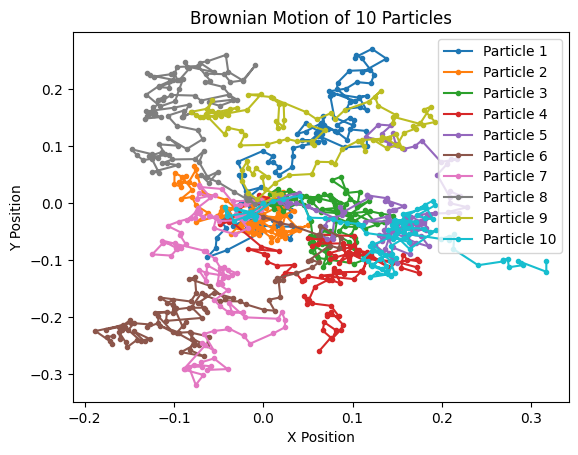

In [17]:
for n in range(10):
    plt.plot(x[:,n], y[:,n],'.-', label=f"Particle {n+1}")
plt.title("Brownian Motion of 10 Particles")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()

## Lennard Jones interaction between particles

In [18]:
# Parameters
num_particles = 10  # Number of particles
runs = 1000         # Number of time steps
delta = 0.01        # Time step size
epsilon = 1.0       # Lennard-Jones potential depth
sigma = 1.0         # Lennard-Jones distance parameter
thermal_factor = np.sqrt(2) * delta  # Thermal motion scaling factor

# Initialize particle positions randomly in a 2D space
np.random.seed(36)  # For reproducibility
positions = (np.random.rand(num_particles, 2)-0.5) * 10  # Random positions in a 10x10 box

# Initialize arrays to store trajectories
trajectories_x = np.zeros((runs, num_particles))
trajectories_y = np.zeros((runs, num_particles))
trajectories_x[0, :] = positions[:, 0]
trajectories_y[0, :] = positions[:, 1]

def lennard_jones_force(positions,epsilon):
    num_particles = positions.shape[0]
    forces = np.zeros_like(positions)  # Initialize forces to zero

    for i in range(num_particles):
        for j in range(num_particles):
            if i == j:
                continue
            # Compute the displacement vector and distance
            displacement = positions[i] - positions[j]
            distance = np.linalg.norm(displacement)
            
            # Avoid division by zero
            if distance == 0 or distance < sigma:
                continue
            
            # Compute the Lennard-Jones force
            force_magnitude = 24 * epsilon * (2 * (sigma / distance)**13 - (sigma / distance)**7) / distance
            forces[i] += force_magnitude * (displacement / distance)  # Add force contribution

    return forces

# Simulation loop
for t in range(1, runs):
    # Compute Lennard-Jones forces
    forces = lennard_jones_force(positions,epsilon)
    
    # Update positions with thermal motion and Lennard-Jones forces
    thermal_motion = thermal_factor * np.random.normal(0, 1, positions.shape)
    positions += thermal_motion - delta**2 * forces
    
    # Store trajectories
    trajectories_x[t, :] = positions[:, 0]
    trajectories_y[t, :] = positions[:, 1]

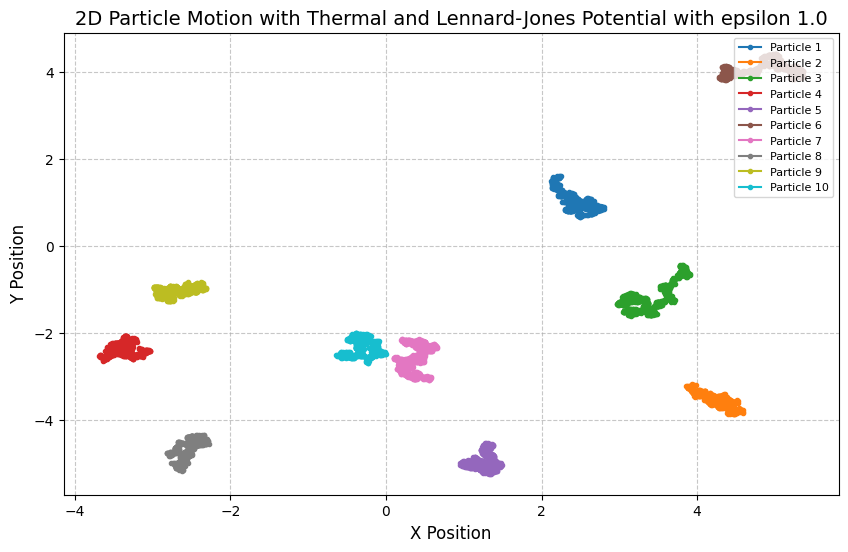

In [19]:
# Plot the trajectories of particles
plt.figure(figsize=(10, 6))
for n in range(num_particles):
    plt.plot(trajectories_x[:, n], trajectories_y[:, n],".-", label=f"Particle {n + 1}")

plt.title(f"2D Particle Motion with Thermal and Lennard-Jones Potential with epsilon {epsilon}", fontsize=14)
plt.xlabel("X Position", fontsize=12)
plt.ylabel("Y Position", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=8)
# plt.xlim(-20,20)
# plt.ylim(-20,20)
plt.show()

In [20]:
epsilon = 0.1       # Lennard-Jones potential depth

# Initialize particle positions randomly in a 2D space
np.random.seed(36)  # For reproducibility
positions = (np.random.rand(num_particles, 2)-0.5) * 10  # Random positions in a 10x10 box

# Initialize arrays to store trajectories
trajectories_x = np.zeros((runs, num_particles))
trajectories_y = np.zeros((runs, num_particles))
trajectories_x[0, :] = positions[:, 0]
trajectories_y[0, :] = positions[:, 1]

# Simulation loop
for t in range(1, runs):
    # Compute Lennard-Jones forces
    forces = lennard_jones_force(positions,epsilon)
    
    # Update positions with thermal motion and Lennard-Jones forces
    thermal_motion = thermal_factor * np.random.normal(0, 1, positions.shape)
    positions += thermal_motion - delta**2 * forces
    
    # Store trajectories
    trajectories_x[t, :] = positions[:, 0]
    trajectories_y[t, :] = positions[:, 1]

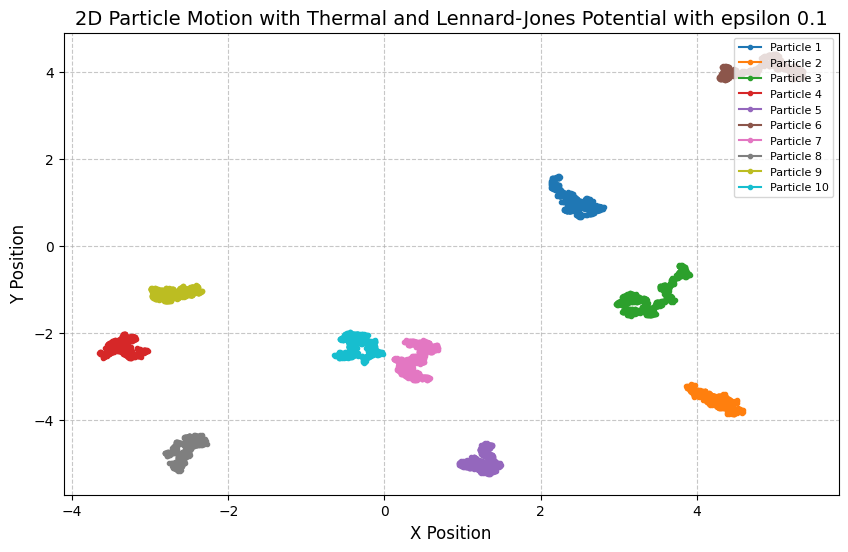

In [21]:
# Plot the trajectories of particles
plt.figure(figsize=(10, 6))
for n in range(num_particles):
    plt.plot(trajectories_x[:, n], trajectories_y[:, n],".-", label=f"Particle {n + 1}")

# Add plot details
plt.title(f"2D Particle Motion with Thermal and Lennard-Jones Potential with epsilon {epsilon}", fontsize=14)
plt.xlabel("X Position", fontsize=12)
plt.ylabel("Y Position", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=8)
# plt.xlim(-20,20)
# plt.ylim(-20,20)
plt.show()